In [1]:
# Sel ini menghasilkan TIGA dataset cabang (kota) terpisah untuk Tugas Mandiri Pertemuan 3
import numpy as np
import pandas as pd

kategori_list = ["Elektronik", "Fashion", "Makanan & Minuman", "Kesehatan & Kecantikan", "Rumah Tangga"]
metode_bayar_list = ["Transfer Bank", "E-Wallet", "COD", "Kartu Kredit"]
tanggal_range = pd.date_range("2026-08-01", "2026-08-31", freq="D")

cabang_kota = {"Magelang": 101, "Yogyakarta": 202, "Semarang": 303}

for kota, seed in cabang_kota.items():
    np.random.seed(seed)  # seed berbeda tiap kota agar datanya bervariasi, namun tetap konsisten/reproducible
    n = 200
    data_cabang = {
        "order_id": [f"{kota[:3].upper()}-{2000 + i}" for i in range(n)],
        "tanggal": np.random.choice(tanggal_range, size=n),
        "kategori": np.random.choice(kategori_list, size=n, p=[0.25, 0.25, 0.20, 0.15, 0.15]),
        "unit_terjual": np.random.randint(1, 8, size=n),
        "harga_satuan": np.random.choice([25000, 50000, 75000, 100000, 150000, 250000], size=n),
        "metode_pembayaran": np.random.choice(metode_bayar_list, size=n),
    }
    df_cabang = pd.DataFrame(data_cabang)
    df_cabang["kota"] = kota
    nama_file = f"transaksi_{kota.lower()}.csv"
    df_cabang.to_csv(nama_file, index=False)
    print(f"Berkas '{nama_file}' berhasil dibuat: {df_cabang.shape[0]} baris")

print("\nKetiga berkas CSV cabang siap digunakan untuk Tugas Mandiri.")

Berkas 'transaksi_magelang.csv' berhasil dibuat: 200 baris
Berkas 'transaksi_yogyakarta.csv' berhasil dibuat: 200 baris
Berkas 'transaksi_semarang.csv' berhasil dibuat: 200 baris

Ketiga berkas CSV cabang siap digunakan untuk Tugas Mandiri.


In [2]:
# Membuat directory.
!hdfs dfs -mkdir -p /user/caitlyn/ecommerce/raw
!hdfs dfs -mkdir -p /user/caitlyn/ecommerce/processed

In [3]:
# Mengunggah ketiga file CSV ke direktori raw
!hdfs dfs -put transaksi_magelang.csv /user/caitlyn/ecommerce/raw/
!hdfs dfs -put transaksi_yogyakarta.csv /user/caitlyn/ecommerce/raw/
!hdfs dfs -put transaksi_semarang.csv /user/caitlyn/ecommerce/raw/

# Menampilkan isi direktori raw untuk verifikasi (lengkap dengan ukuran file)
!hdfs dfs -ls /user/caitlyn/ecommerce/raw

Found 3 items
-rw-r--r--   1 caitlyn supergroup      12329 2026-09-09 17:23 /user/caitlyn/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 caitlyn supergroup      12154 2026-09-09 17:23 /user/caitlyn/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 caitlyn supergroup      12684 2026-09-09 17:23 /user/caitlyn/ecommerce/raw/transaksi_yogyakarta.csv


In [1]:
import os
import subprocess
import pandas as pd

# 1. Menarik informasi CLASSPATH dari sistem Hadoop dan menyimpannya ke memori Python
os.environ["CLASSPATH"] = subprocess.check_output(["hadoop", "classpath", "--glob"]).decode('utf-8').strip()

# 2. Menentukan jalur (path) langsung ke HDFS
path_mgl = "hdfs://localhost:9000/user/caitlyn/ecommerce/raw/transaksi_magelang.csv"
path_yog = "hdfs://localhost:9000/user/caitlyn/ecommerce/raw/transaksi_yogyakarta.csv"
path_smg = "hdfs://localhost:9000/user/caitlyn/ecommerce/raw/transaksi_semarang.csv"

# 3. Membaca data langsung dari HDFS
df_magelang = pd.read_csv(path_mgl)
df_yogyakarta = pd.read_csv(path_yog)
df_semarang = pd.read_csv(path_smg)

# 4. Menggabungkan ketiga DataFrame menjadi satu
df_gabungan = pd.concat([df_magelang, df_yogyakarta, df_semarang], ignore_index=True)

# 5. Membuktikan hasil gabungan
df_gabungan["kota"].value_counts()

2026-09-09 19:37:06,024 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64

In [2]:
# 1. Menambahkan kolom total_pendapatan
df_gabungan["total_pendapatan"] = df_gabungan["unit_terjual"] * df_gabungan["harga_satuan"]

# 2. Membuat tabel ringkasan (groupby kota dan kategori)
ringkasan_kota_kategori = df_gabungan.groupby(["kota", "kategori"])["total_pendapatan"].sum().reset_index()

# 3. Menyimpan kedua hasil ke disk lokal (format CSV)
df_gabungan.to_csv("data_gabungan_bersih.csv", index=False)
ringkasan_kota_kategori.to_csv("ringkasan_kota_kategori.csv", index=False)

# Menampilkan sedikit hasil ringkasan untuk dicek laprak
ringkasan_kota_kategori.head()

,kota,kategori,total_pendapatan
0,Magelang,Elektronik,18775000
1,Magelang,Fashion,27750000
2,Magelang,Kesehatan & Kecantikan,17375000
3,Magelang,Makanan & Minuman,17525000
4,Magelang,Rumah Tangga,12200000


In [3]:
# Mengunggah hasil olahan dari lokal ke direktori processed HDFS
!hdfs dfs -put data_gabungan_bersih.csv /user/caitlyn/ecommerce/processed/
!hdfs dfs -put ringkasan_kota_kategori.csv /user/caitlyn/ecommerce/processed/

# Verifikasi file sudah masuk ke direktori processed
!hdfs dfs -ls /user/caitlyn/ecommerce/processed

Found 2 items
-rw-r--r--   1 caitlyn supergroup      41257 2026-09-09 19:39 /user/caitlyn/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 caitlyn supergroup        530 2026-09-09 19:39 /user/caitlyn/ecommerce/processed/ringkasan_kota_kategori.csv


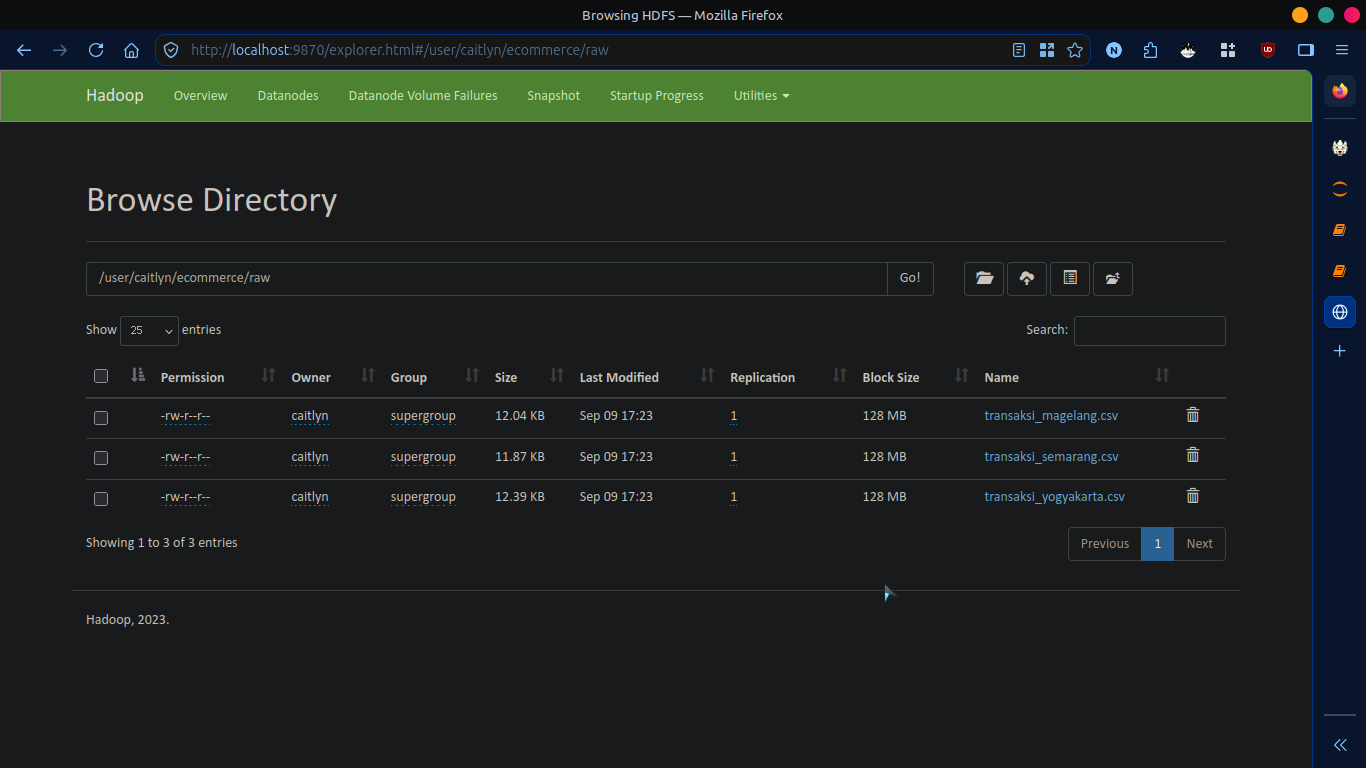

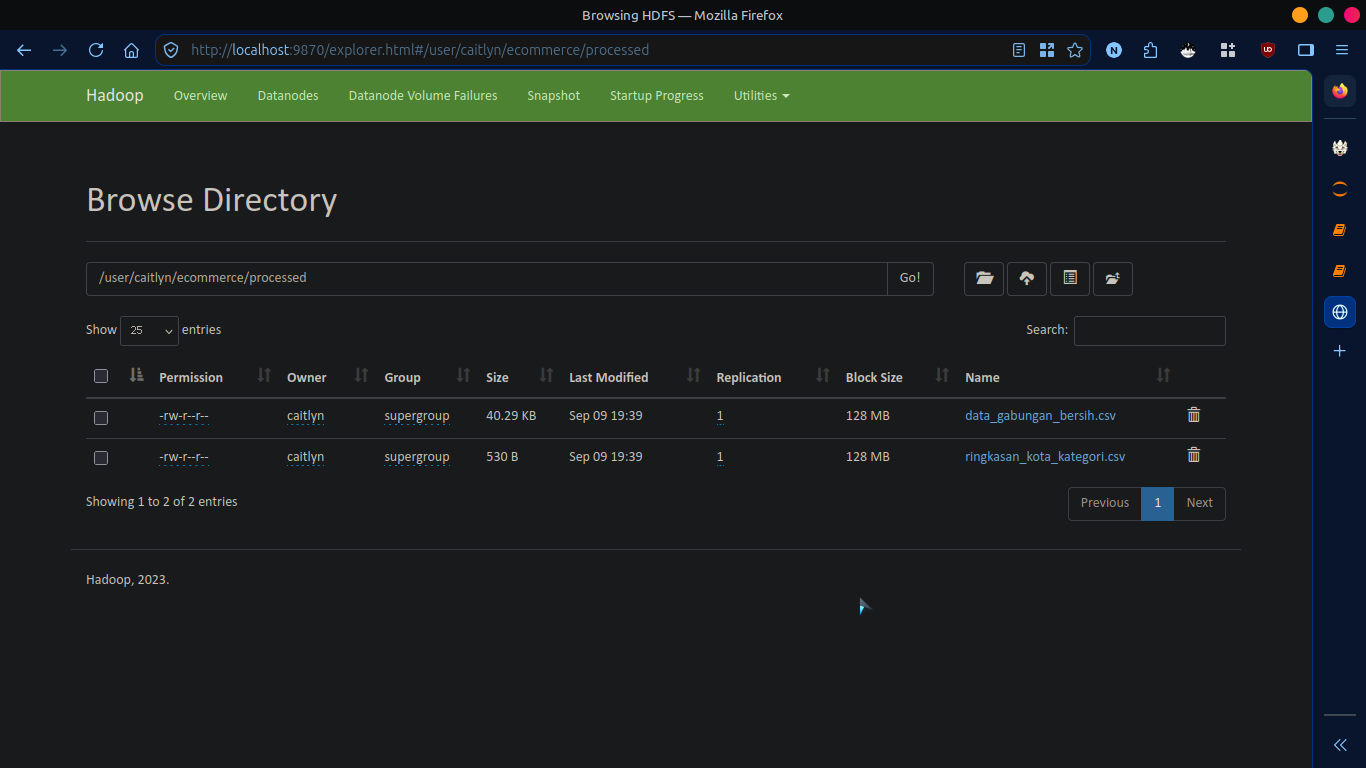

Refleksi Pemisahan Data HDFS.
Memisahkan data mentah (raw) dengan data olahan (processed) dalam struktur direktori HDFS memberikan beberapa keuntungan krusial dibandingkan mencampurnya dalam satu tempat. Keuntungan pertama ada pada keamanan (menjaga integritas) data asli. Alasannya, karena data di folder raw bertindak sebagai data sumber (istilah resminya: Single Source of Truth) yang tidak boleh diubah (imutabel). Tujuannya semata-mata hanya untuk jaga-jaga—jika sewaktu-waktu terjadi kesalahan dalam proses pengolahan algoritma atau manipulasi data, kita selalu dapat melakukan proses ulang dari titik nol tanpa kehilangan data transaksi aslinya. Sementara untuk keuntungan kedua, terletak pada kemudahan dalam hal manajemen hak akses antar tim. Tim analis (atau business intelligence) dapat diberikan akses khusus ke folder processed yang sudah bersih dan siap pakai, tanpa harus memilah-milah data atau mengambil risiko merusak data asli di folder raw.